### 🤖 Multi Agent Suprvisor With RAG
Supervisor is a multi-agent architecture where specialized agents are coordinated by a central supervisor agent. The supervisor agent controls all communication flow and task delegation, making decisions about which agent to invoke based on the current context and task requirements.

In this tutorial, you will build a supervisor system with two agents — a research and a math expert. By the end of the tutorial you will:

1. Build specialized research and math agents
2. Build a supervisor for orchestrating them with the prebuilt langgraph-supervisor
3. Build a supervisor 
4. Implement advanced task delegation

In [ ]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.tools.retriever import create_retriever_tool
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_tavily import TavilySearch
from langchain.agents import create_agent
from IPython.display import Markdown, display
from langchain_core.tools import tool
from langgraph_supervisor import create_supervisor

In [3]:
load_dotenv()

True

In [4]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else: 
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

In [5]:
llm = init_chat_model("openai:gpt-4o")

In [ ]:
# Tools Definitions: Research Agent
#=======================
# 1. Tavily Search Tool
#------------------------
tavily_tool=TavilySearch(max_results=5)

# 2. Retriever Tool
#------------------------
# create retriever tool for research agent
docs=TextLoader('internal_docs.txt',encoding="utf-8").load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
vs = FAISS.from_documents(chunks, OpenAIEmbeddings())
retriever = vs.as_retriever()

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_tool_research_node",
    "Retriever Tool for the Research Node"
)

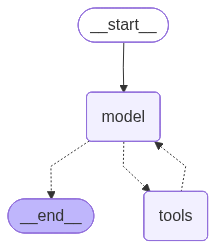

In [7]:
research_agent=create_agent(
    model=llm,
    tools=[tavily_tool, retriever_tool],
    system_prompt=(
        """
        You are a research agent.

        INSTRUCTIONS:
        - Assist ONLY with research-related tasks, DO NOT do any math.
        - After you're done with your tasks, respond to the supervisor directly.
        - Respond ONLY with the results of your work, do NOT include ANY other text.
        """
    ),
    name="research_agent"
)
research_agent

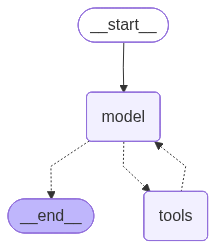

In [8]:
# Tools Definitions: Math Agent
#==================================

@tool("addition_tool")
def add(a: float, b: float) -> float:
    """
    Add two numbers.
    Args:
        a: First number
        b: Second number
    """
    return a + b


@tool
def divide(a: float, b: float) -> float:
    """
    Divide two numbers.
    Args:
        a: First number
        b: Second number
    """
    if b == 0:
        raise ValueError("Cannot divide by zero")
    return a / b


@tool
def multiply(a: float, b: float) -> float:
    """
    Multiply two numbers.
    Args:
        a: First number
        b: Second number
    """
    return a * b

math_agent=create_agent(
    model=llm,
    tools=[add,multiply,divide],
    system_prompt=(
        """
        You are a math agent."
        
        INSTRUCTIONS:
        - Assist ONLY with math-related tasks.
        - After you're done with your tasks, respond to the supervisor directly.
        - Respond ONLY with the results of your work, do NOT include ANY other text.
        """
    ),
    name="math_agent"

)

math_agent

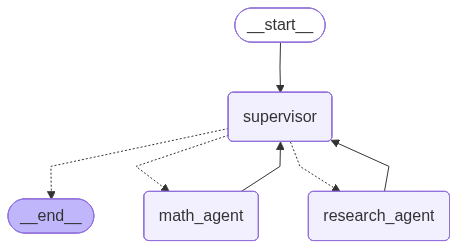

In [9]:
supervisor=create_supervisor(
    model=llm,
    agents=[research_agent,math_agent],
    prompt=(
        """
        You are a supervisor managing two agents:
        - a research agent. Assign research-related tasks to this agent.
        - a math agent. Assign math-related tasks to this agent.
        Assign work to one agent at a time, do not call agents in parallel.
        Do not do any work yourself.
        """
    ),
    add_handoff_back_messages=True,
    output_mode="full_history"
).compile()

supervisor

In [10]:
response=supervisor.invoke(
    {
        "messages":" list all the transformer variants in production deployments from the retriever and then tell me what is 5 plus 10"
    }
)

In [11]:
display(Markdown(response["messages"][-1].content))

The list of transformer variants used in production deployments includes EfficientFormer, Vision Transformers (ViT and Swin Transformer), Speech Transformers (Wav2Vec 2.0), and Reformer. For the math query, the result of 5 plus 10 is 15.